## Импорты библиотек

In [1]:
import math
import random
import warnings
import joblib
from datetime import datetime, timedelta
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import ast
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import shap

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

## Конфигурация путей и фиксация seed

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

DATA_DIR = Path('data')
ARTIFACTS_DIR = Path('artifacts')
OUTPUT_DIR = Path('output')

for _dir in [DATA_DIR, ARTIFACTS_DIR, OUTPUT_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

## Чтение датасета сотрудников

**Входные данные о сотрудниках будут подаваться через API**

In [3]:
employees_path = DATA_DIR / 'employees_inference.csv'

if not employees_path.exists():
    raise FileNotFoundError(f"Файл {employees_path} не найден.")

df_employees = pd.read_csv(employees_path, encoding='utf-8-sig')

list_columns = ['languages', 'technologies']
for col in list_columns:
    if col in df_employees.columns:
        df_employees[col] = df_employees[col].apply(
            lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) else x
        )

date_columns = ['hire_date', 'last_promotion_date']
for col in date_columns:
    if col in df_employees.columns:
        df_employees[col] = pd.to_datetime(df_employees[col], errors='coerce')

print(f"Прочитано {len(df_employees)} данных о сотрудниках")

Прочитано 200 данных о сотрудниках


Вывод первых 5 сотрудников на предпросмотр

In [4]:
df_employees.head()

,employee_id,department,job_level,location,employment_type,fte_percentage,tenure_years,time_in_current_role_years,performance_rating,engagement_score,base_salary_monthly,bonus_target_pct,turnover_risk_score,languages,technologies,training_hours_ytd,manager_id,hire_date,last_promotion_date
0,EMP-10210,Sales,L4,Екатеринбург,Полная занятость,1.0,6.8,6.8,3.94,3.77,322463,0.2,0.188,"[Scala, Rust, Go]","[Node.js, DevOps]",16,EMP-10131,2019-07-04,2019-12-02
1,EMP-10281,Finance,L3,Екатеринбург,Полная занятость,1.0,9.4,9.4,3.66,3.77,240881,0.2,0.151,[TypeScript],"[TensorFlow, Cloud]",22,EMP-10356,2016-12-10,2018-11-07
2,EMP-10034,Operations,L1,СПб,Полная занятость,1.0,10.8,1.9,3.97,4.60,165506,0.1,0.150,"[TypeScript, Scala, C#]","[PostgreSQL, Node.js]",26,NaN,2015-07-24,2015-12-13
3,EMP-10211,HR,L1,СПб,Полная занятость,1.0,5.1,2.0,3.58,4.50,130248,0.0,0.205,[TypeScript],"[Node.js, Cloud, dbt]",31,NaN,2021-04-11,2023-06-06
4,EMP-10094,Finance,L1,СПб,Полная занятость,1.0,2.3,0.6,3.67,4.67,121250,0.0,0.199,"[SQL, C#]","[Cloud, Spark]",18,NaN,2024-01-03,2024-07-04


## Инференс модели и выборка по формуле редких событий

Установка модели

In [5]:
model_path = ARTIFACTS_DIR / "rf_model.joblib"

if not model_path.exists():
    raise FileNotFoundError(
        f"Файл модели не найден по пути: {model_path}\n"
        "Запустите сначала ноутбук с обучением."
    )

model = joblib.load(model_path)

print(f"Модель успешно загружена")

Модель успешно загружена


Функция генерации команд из списка сотрудников

In [6]:
FEATURE_COLS = [
    'team_size', 'skill_coverage', 'avg_performance', 'avg_engagement', 'avg_turnover_risk', 'senior_ratio', 'budget_fit', 'timeline_days', 'budget_limit'
]

def generate_candidates_and_predict(model: RandomForestRegressor, df_emp: pd.DataFrame, config: Dict, n_samples: int = 12000) -> pd.DataFrame:
    req_skills = set(config['req_languages'] + config['req_technologies'])
    timeline = config['timeline_days']
    budget = config['budget_limit']
    candidates = []
    
    for _ in range(n_samples):
        size = np.random.randint(config['min_team_size'], config['max_team_size'] + 1)
        idx = np.random.choice(len(df_emp), size=size, replace=False)
        team = df_emp.iloc[idx]
        
        cost = team['base_salary_monthly'].sum() * (timeline / 30.0)
        if cost > budget: continue # Фильтруем по бюджету проекта
            
        lang_set = set().union(*[set(l) for l in team['languages'] if isinstance(l, (list, tuple))])
        tech_set = set().union(*[set(t) for t in team['technologies'] if isinstance(t, (list, tuple))])
        cov = len(req_skills.intersection(lang_set | tech_set)) / len(req_skills)
        if cov < 0.3: continue # Фильтруем по покрытию навыками
            
        candidates.append({
            'team_size': size,
            'skill_coverage': cov,
            'avg_performance': team['performance_rating'].mean(),
            'avg_engagement': team['engagement_score'].mean(),
            'avg_turnover_risk': team['turnover_risk_score'].mean(),
            'senior_ratio': (team['job_level'].isin(['L4','L5','L6'])).mean(),
            'budget_fit': 1.0, 'timeline_days': timeline, 'budget_limit': budget,
            'team_ids': ', '.join(team['employee_id'])
        })
        
    if not candidates:
        return pd.DataFrame(columns=FEATURE_COLS + ['team_ids', 'predicted_success', 'ci_low', 'ci_high'])
        
    X_cand = pd.DataFrame(candidates)
    X_feat = X_cand[FEATURE_COLS].reindex(columns=FEATURE_COLS, fill_value=0.0)
    preds = model.predict(X_feat)
    
    n_boot = 40
    boot_preds = np.array([
        model.predict(X_feat + np.random.normal(0, 0.015, X_feat.shape)) for _ in range(n_boot)
    ])
    ci_low = np.percentile(boot_preds, 2.5, axis=0)
    ci_high = np.percentile(boot_preds, 97.5, axis=0)
    
    X_cand['predicted_success'] = preds
    X_cand['ci_low'] = ci_low
    X_cand['ci_high'] = ci_high
    return X_cand

**Входные данные о конфигурации проекта будут подаваться через API**

In [7]:
PROJECT_CONFIG = {
    'name': 'AI Dashboard',
    'req_languages': ['Python', 'SQL', 'Go'],
    'req_technologies': ['DevOps', 'Cloud', 'ML', 'Data Engineering'],
    'timeline_days': 90,
    'budget_limit': 4_500_000,
    'min_team_size': 3,
    'max_team_size': 5
}

Генерация команд и фильтр

In [12]:
df_candidates = generate_candidates_and_predict(model, df_employees, PROJECT_CONFIG, n_samples=12000)
print(f"Прошло фильтров: {len(df_candidates)} из 12 000 команд")

df_candidates.head()

Прошло фильтров: 8967 из 12 000 команд


,team_size,skill_coverage,avg_performance,avg_engagement,avg_turnover_risk,senior_ratio,budget_fit,timeline_days,budget_limit,team_ids,predicted_success,ci_low,ci_high
0,4,0.714286,2.7075,4.032500,0.18875,0.250000,1.0,90,4500000,"EMP-10335, EMP-10230, EMP-10169, EMP-10173",0.683927,0.659345,0.689680
1,5,0.857143,3.4840,3.600000,0.16240,0.000000,1.0,90,4500000,"EMP-10256, EMP-10199, EMP-10292, EMP-10077, EM...",0.757348,0.749771,0.775937
2,3,0.571429,3.5100,4.333333,0.18600,0.333333,1.0,90,4500000,"EMP-10076, EMP-10308, EMP-10115",0.741074,0.731259,0.742633
3,5,0.428571,3.1440,3.722000,0.17920,0.200000,1.0,90,4500000,"EMP-10149, EMP-10374, EMP-10276, EMP-10219, EM...",0.626429,0.621519,0.628585
4,5,0.714286,3.7820,3.638000,0.16400,0.400000,1.0,90,4500000,"EMP-10354, EMP-10158, EMP-10203, EMP-10149, EM...",0.744960,0.744041,0.750065


## SHAP и контрфактуальный анализ

In [13]:
def analyze_top_teams(model: RandomForestRegressor, df_candidates: pd.DataFrame, top_n: int = 10) -> Tuple[pd.DataFrame, np.ndarray]:
    top_teams = df_candidates.nlargest(top_n, 'predicted_success').copy().reset_index(drop=True)
    top_teams['rank'] = top_teams.index + 1
    
    X_top = top_teams[FEATURE_COLS]
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_top)
    
    drivers_list = []
    for i in range(len(top_teams)):
        top_idx = np.argsort(np.abs(shap_values[i]))[::-1][:2]
        drv = []
        for j in top_idx:
            sign = "+" if shap_values[i, j] > 0 else ""
            drv.append(f"{FEATURE_COLS[j]} ({sign}{shap_values[i, j]*100:.0f}%)")
        drivers_list.append(" | ".join(drv))
    top_teams['key_drivers'] = drivers_list
    
    cf_rules = []
    for _, row in top_teams.iterrows():
        if row['predicted_success'] >= 0.85:
            cf_rules.append("Оптимальный баланс. Масштабировать без изменений.")
        elif row['skill_coverage'] < 0.75:
            cf_rules.append("Добавить Fullstack/DevOps → покрытие стека ↑")
        elif row['avg_turnover_risk'] > 0.25:
            cf_rules.append("Заменить участника с высоким риском ухода → стабильность ↑")
        elif row['senior_ratio'] < 0.25:
            cf_rules.append("Включить L4+ специалиста → архитектурные риски ↓")
        else:
            cf_rules.append("Рассмотреть замену для повышения среднего Performance → успех ↑")
    top_teams['counterfactual'] = cf_rules
    return top_teams, shap_values

In [14]:
df_top, shap_vals_top = analyze_top_teams(model, df_candidates, top_n=10)

## Визуализация и экспорт артефактов

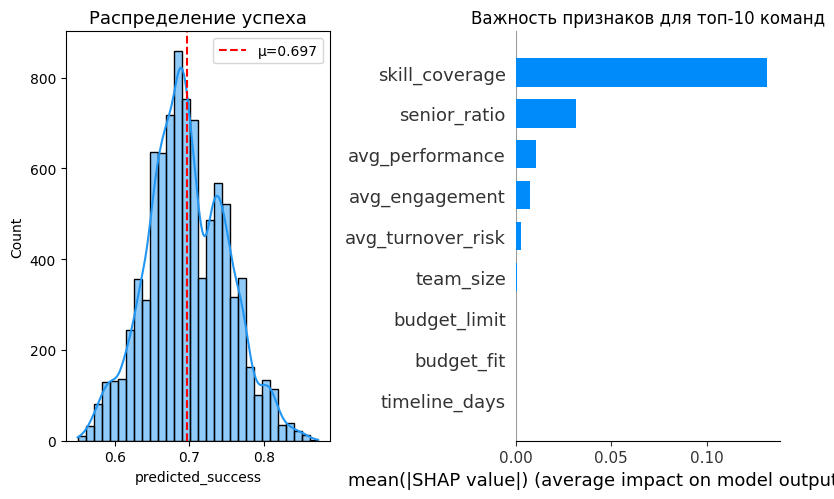

Отчет сохранен: output\decision_package.csv


,rank,team_ids,predicted_success,key_drivers,counterfactual,95%_ДИ,economic_benefit_per_proj,annual_economic_benefit
0,1,"EMP-10104, EMP-10148, EMP-10282, EMP-10210",87.3%,skill_coverage (+11%) | senior_ratio (+5%),Оптимальный баланс. Масштабировать без изменений.,[87%; 88%],290893.09,5817861.81
1,2,"EMP-10079, EMP-10312, EMP-10148, EMP-10025",86.2%,skill_coverage (+13%) | senior_ratio (+3%),Оптимальный баланс. Масштабировать без изменений.,[85%; 86%],295038.08,5900761.62
2,3,"EMP-10038, EMP-10295, EMP-10115",86.1%,skill_coverage (+14%) | senior_ratio (+4%),Оптимальный баланс. Масштабировать без изменений.,[85%; 87%],295409.72,5908194.35
3,4,"EMP-10148, EMP-10140, EMP-10079, EMP-10026",86.0%,skill_coverage (+13%) | senior_ratio (+1%),Оптимальный баланс. Масштабировать без изменений.,[85%; 86%],295882.57,5917651.30
4,5,"EMP-10025, EMP-10079, EMP-10115",86.0%,skill_coverage (+12%) | senior_ratio (+4%),Оптимальный баланс. Масштабировать без изменений.,[85%; 87%],295978.05,5919561.01
5,6,"EMP-10338, EMP-10110, EMP-10321, EMP-10115, EM...",85.8%,skill_coverage (+13%) | senior_ratio (+3%),Оптимальный баланс. Масштабировать без изменений.,[85%; 86%],296919.54,5938390.85
6,7,"EMP-10069, EMP-10199, EMP-10330, EMP-10383",85.8%,skill_coverage (+14%) | senior_ratio (+3%),Оптимальный баланс. Масштабировать без изменений.,[85%; 86%],296998.81,5939976.10
7,8,"EMP-10343, EMP-10292, EMP-10156, EMP-10148",85.7%,skill_coverage (+15%) | senior_ratio (+2%),Оптимальный баланс. Масштабировать без изменений.,[85%; 86%],297202.00,5944039.94
8,9,"EMP-10256, EMP-10019, EMP-10292, EMP-10350, EM...",85.6%,skill_coverage (+14%) | senior_ratio (+3%),Оптимальный баланс. Масштабировать без изменений.,[84%; 86%],297757.77,5955155.33
9,10,"EMP-10126, EMP-10330, EMP-10372, EMP-10082, EM...",85.5%,skill_coverage (+13%) | senior_ratio (+4%),Оптимальный баланс. Масштабировать без изменений.,[85%; 86%],297843.89,5956877.72


In [15]:
def calculate_economic_impact(project_success: float, timeline_days: int, n_projects_year: int = 20) -> Dict[str, float]:
    risk_avoided = 400_000 * (1 - project_success)
    time_saved = 60_000
    turnover_saved = 180_000
    
    total_per_project = risk_avoided + time_saved + turnover_saved
    return {
        'per_project': round(total_per_project, 2),
        'annual': round(total_per_project * n_projects_year, 2)
    }

def visualize_and_export(df_candidates: pd.DataFrame, df_top: pd.DataFrame, shap_vals: np.ndarray,output_path: str = 'decision_package.csv') -> pd.DataFrame:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.histplot(df_candidates['predicted_success'], bins=30, kde=True, ax=axes[0], color='#2196F3')
    axes[0].set_title('Распределение успеха', fontsize=13)
    axes[0].axvline(df_candidates['predicted_success'].mean(), color='r', linestyle='--', label=f'μ={df_candidates["predicted_success"].mean():.3f}')
    axes[0].legend()
    
    plt.sca(axes[1])  
    shap.summary_plot(shap_vals, df_top[FEATURE_COLS], plot_type="bar", show=False)
    axes[1].set_title('Важность признаков для топ-10 команд', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "shap_success_dist.png", dpi=150)
    plt.show()
    
    cols_final = ['rank', 'team_ids', 'predicted_success', 'key_drivers', 'counterfactual']
    report = df_top[cols_final].copy()
    report['predicted_success'] = (report['predicted_success'] * 100).round(1).astype(str) + '%'
    report['95%_ДИ'] = "[" + (df_top['ci_low']*100).round(0).astype(int).astype(str) + "%; " + (df_top['ci_high']*100).round(0).astype(int).astype(str) + "%]"
    
    eco = df_top.apply(lambda r: calculate_economic_impact(r['predicted_success'], PROJECT_CONFIG['timeline_days']), axis=1)
    report['economic_benefit_per_proj'] = [x['per_project'] for x in eco]
    report['annual_economic_benefit'] = [x['annual'] for x in eco]
    
    final_path = OUTPUT_DIR / output_path
    report.to_csv(final_path, index=False, encoding='utf-8-sig')
    print(f"Отчет сохранен: {final_path}")
    return report

final_report = visualize_and_export(df_candidates, df_top, shap_vals_top)
display(final_report.head(10))